# Project: Medical Insurance Cost Prediction

An insurance company wants to predict the annual medical insurance charges of a customer based on:
```
Age
Gender
BMI
Number of Children
Smoking Status
Region
```
Target:

> Insurance Charges

  > [Dataset url](https://www.kaggle.com/datasets/mirichoi0218/insurance)

  In depth question meaning :
 1. What is the Core Objective?The goal is to predict a customer's expected annual medical bills based on their personal profile (Age, BMI, Smoking Status, etc.). The company uses this prediction to calculate a fair and safe monthly or annual fee (called a premium) for the customer to pay.

 2. Why does the Company have to Predict this Amount? (The Financial Risk)

 An insurance company operates on the principle of managing risk.
 - The Risk Factor: High-risk individuals (such as smokers, older individuals, or those with a high BMI) are statistically much more likely to get sick, undergo surgeries, or require long hospital stays.
 - The Financial Burden: When a customer falls ill, the insurance company is legally obligated to pay those massive medical bills to the hospital on behalf of the customer.
 - The Business Impact: If the company does not accurately predict these high costs before signing a contract with the user, they will undercharge the customer. If a customer pays only $1,000 in premiums but runs up $50,000 in hospital bills, the company loses $49,000. If this happens with thousands of customers, the company will face bankruptcy (financial risk).

 3. Summary of the GoalTo prevent financial loss, the company must use Machine Learning to predict the correct annual medical cost of a customer upfront. This ensures high-risk individuals are charged a higher, more appropriate rate to absorb their medical expenses, keeping the insurance company profitable and secure.

Why Not Linear Regression?

Linear Regression assumes:

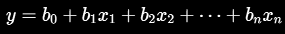

But insurance pricing often behaves like:
```
IF smoker = yes
    charges increase significantly

IF age > 50
    charges increase

IF BMI > 30
    risk increases

```
> These are tree-like decision rules.
```
Smoker?
│
├── Yes
│     ├── BMI > 30
│     │      → High Charges
│     └── BMI <= 30
│            → Medium Charges
│
└── No
      ├── Age > 50
      │      → Moderate Charges
      └── Age <= 50
             → Low Charges
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [21]:
df = pd.read_csv('/content/insurance.csv')  # by this command we can render the csv file data into runtime colab
df.head() # this command is used to render top 5 row's

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Info table")
df.info()

print("--------------------------------------------------")
print("Describe table")
df.describe()

Info table
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
--------------------------------------------------
Describe table


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isnull() #this will show the table (if null : True else : False)

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [6]:
df.isnull().sum() # this command is to give total number of null values in a column

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# EDA


<Axes: xlabel='charges', ylabel='Count'>

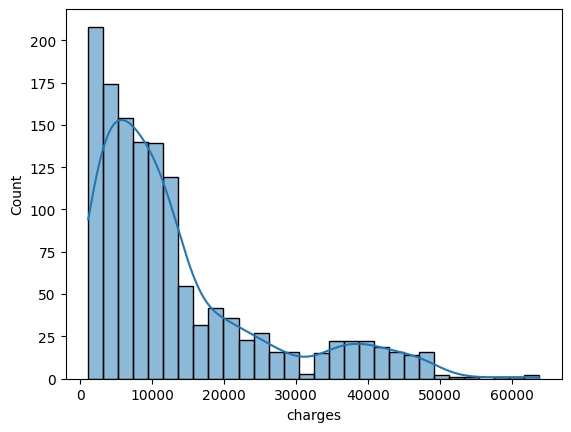

In [8]:
# Target Distribution

sns.histplot(df["charges"], kde=True) # this graph tells use about how many time's 10k charges appered like that

<Axes: xlabel='age', ylabel='charges'>

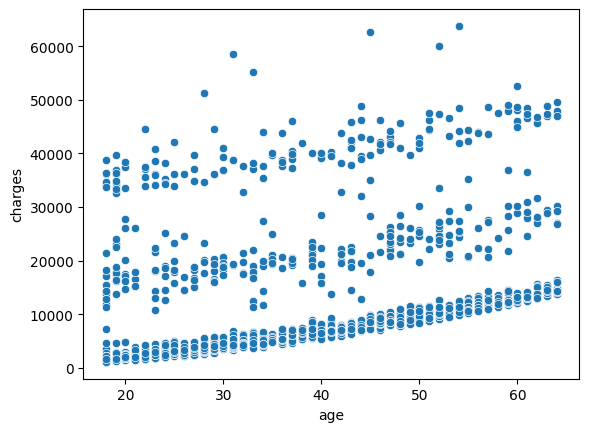

In [9]:
# Age vs Charges
sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

<Axes: xlabel='smoker', ylabel='charges'>

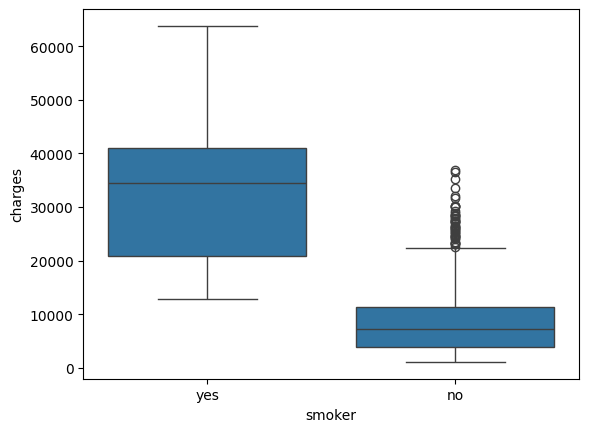

In [10]:
# Smoker vs Charges
sns.boxplot(
    x="smoker",
    y="charges",
    data=df
)

# from the above graph we can say
1) if Somker == yes :

        - then mostly the charge's is b/w 20k - 40k & mid is 35k
2) if Smoker == no:

        - from this we can observe  even though the user was non somker we can see outlayers ( even though they are non smoker they are also paying charges as like smoker's which is very wrong)  

<Axes: xlabel='bmi', ylabel='charges'>

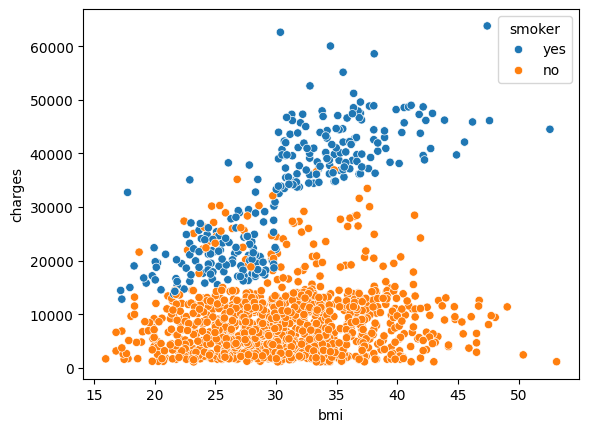

In [11]:
# BMI vs Charges
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=df
)

In [22]:
# Encoding:
# Decision Trees require numerical input.
# Encode:
#  sex ,smoker ,region
print("Before Encoding : ")
print(df.head())

print("--------------------------------------------------------------------------------------")
print("--------------------------------------------------------------------------------------")
print("After Encoding : ")

label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df['region'] = label_encoder.fit_transform(df['region'])
print(df.head())

Before Encoding : 
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
After Encoding : 
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


After Encoding :

- Sex : Male (1) , Female(0)
- smoker : Yes(1) , No(0)
- region : northwest(1) , southeast(2) ,so onn--   

In [23]:
# Train & Split
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = DecisionTreeRegressor(
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [25]:
#now predect on the test data
y_pred = model.predict(X_test)

In [26]:
# now evaluate the linear regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2_percentage = r2_score(y_test, y_pred) * 100
#Print the final performance results
print(f"Model Accuracy (R² Score): {r2_percentage:.2f}%")
print("---------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Accuracy (R² Score): 68.44%
---------------------------------------
Mean Absolute Error (MAE): 3154.7057
Mean Squared Error (MSE): 49003243.6068
Root Mean Squared Error (RMSE): 7000.2317


Result:

- Training Accuracy → ~100%
- Testing Accuracy → 68.44%

This is classic overfitting.

In [27]:
# Check Training vs Testing Accuracy

train_pred = model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R² :", train_r2)
print("Test R² :", test_r2)

Train R² : 0.9983078124756305
Test R² : 0.6843565603663775


In [28]:
# Improve the Model
# Use pruning:

model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [29]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test,y_pred)*100)

R² Score: 86.45947525848408


#